In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

base_path = "/kaggle/input/" 
emotions_map = {
    '01':'Notr', '02':'Notr', '03':'Mutlu', '04':'Uzgun', 
    '05':'Kizgin', '06':'Korku', '07':'Igrenme', '08':'Saskin'
}

data = []
# Tüm alt klasörleri (Actor_01 vb.) tarar
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".wav"):
            part = file.split('-')
            if len(part) >= 3: # RAVDESS formatı kontrolü
                emotion = emotions_map[part[2]]
                data.append([os.path.join(root, file), emotion])

df = pd.DataFrame(data, columns=['path', 'label'])

if len(df) == 0:
    print("HATA: Dosyalar hala bulunamadı. Lütfen sağ taraftaki veri setinin tam ismine tekrar bak.")
else:
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
    print(f"Başarılı! Toplam Ses Dosyası: {len(df)}")
    print(f"Eğitim seti: {len(train_df)} | Doğrulama seti: {len(val_df)}")

Başarılı! Toplam Ses Dosyası: 2880
Eğitim seti: 2304 | Doğrulama seti: 576


In [2]:
import torch
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import librosa
import numpy as np
from torchvision import transforms

class AudioDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.classes = ['Kizgin', 'Igrenme', 'Korku', 'Mutlu', 'Notr', 'Uzgun', 'Saskin']
        self.label2idx = {l: i for i, l in enumerate(self.classes)}

    def __len__(self): 
        return len(self.df)

    def __getitem__(self, idx):
        y, sr = librosa.load(self.df.iloc[idx]['path'], duration=3, sr=22050)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        S_db = librosa.power_to_db(S, ref=np.max)
        img = (S_db - S_db.min()) / (S_db.max() - S_db.min()) * 255
        img = Image.fromarray(img.astype(np.uint8)).convert('RGB')
        if self.transform: 
            img = self.transform(img)
        return img, self.label2idx[self.df.iloc[idx]['label']]

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [3]:
import torch.nn as nn
from torchvision import models

train_loader = DataLoader(AudioDataset(train_df, transform_train), batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(AudioDataset(val_df, transform_val), batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

class_names = ['Kizgin', 'Igrenme', 'Korku', 'Mutlu', 'Notr', 'Uzgun', 'Saskin']
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 7) 

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

model = model.to("cuda")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


In [4]:
import time
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

print(f"{'Epoch':<10} | {'Train Loss':<12} | {'Val Acc':<10} | {'Süre':<8}")
print("-" * 50)

for epoch in range(35):
    start_time = time.time()
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to("cuda"), labels.to("cuda")
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to("cuda"), labels.to("cuda")
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            v_total += labels.size(0)
            v_correct += predicted.eq(labels).sum().item()
            
    val_acc = 100. * v_correct / v_total
    print(f"{epoch+1:<10} | {running_loss/len(train_loader):<12.4f} | %{val_acc:<9.2f} | {time.time()-start_time:.1f}s")

Epoch      | Train Loss   | Val Acc    | Süre    
--------------------------------------------------
1          | 1.3521       | %64.76     | 114.4s
2          | 0.3912       | %91.15     | 85.5s
3          | 0.0980       | %92.36     | 85.5s
4          | 0.0362       | %95.49     | 84.2s
5          | 0.0175       | %94.44     | 85.4s
6          | 0.0123       | %95.49     | 85.3s
7          | 0.0086       | %94.10     | 85.5s
8          | 0.0068       | %94.79     | 84.9s
9          | 0.0051       | %93.75     | 84.7s
10         | 0.0044       | %94.44     | 84.1s
11         | 0.0037       | %95.49     | 84.0s
12         | 0.0036       | %94.44     | 85.0s
13         | 0.0034       | %95.14     | 83.6s
14         | 0.0029       | %95.49     | 83.9s
15         | 0.0027       | %94.44     | 85.0s
16         | 0.0020       | %94.44     | 85.0s
17         | 0.0021       | %94.44     | 84.4s
18         | 0.0017       | %94.79     | 85.4s
19         | 0.0016       | %94.44     | 85.6s
20   

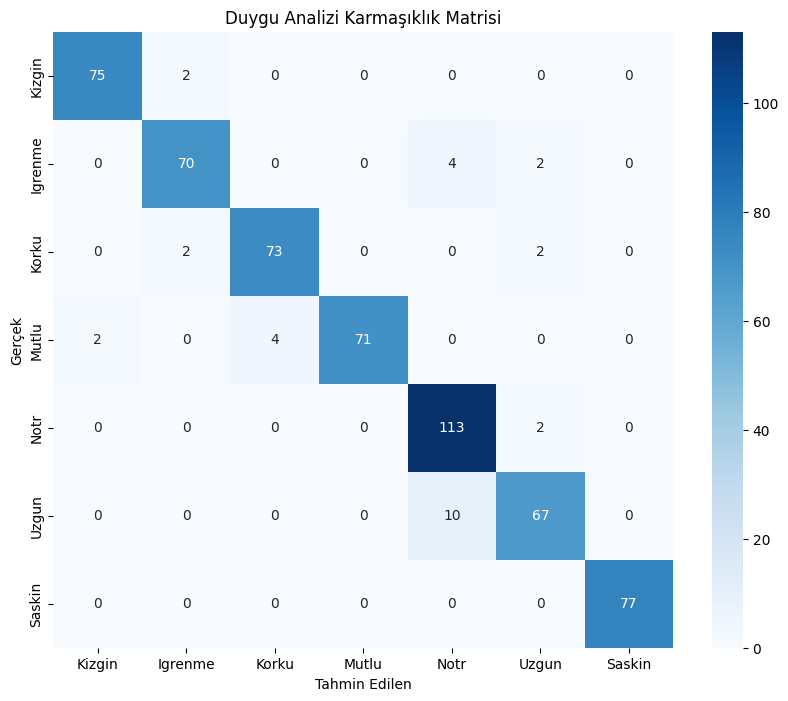

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

torch.save(model.state_dict(), 'ses_duygu_modeli_7sinif.pth')

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to("cuda")
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.title('Duygu Analizi Karmaşıklık Matrisi')
plt.show()